n_steps                 = 160
delay_steps             = 40
len(system_states)      = 161
len(loop_field_states)  = 161
len(output_field_states)= 161
len(input_field_states) = 161
len(correlation_bins)   = 161
len(schmidt)            = 161
len(schmidt_tau)        = 161
psi_final norm          = (1.0000000000000047+0j)
------------------------------------------------------------------------
system norms:
  0  (1+0j)
  1  (1+0j)
  2  (0.9999999999999993+0j)
  3  (1.0000000000000009+0j)
  4  (1.0000000000000029+0j)
loop-field norms:
  0  (1+0j)
  1  (0.9999999999999998+0j)
  2  (0.9999999999999999+0j)
  3  (1.000000000000001+0j)
  4  (1.0000000000000033+0j)
feedback-field norms:
  0  (1+0j)
  1  (0.9999999999999998+0j)
  2  (0.9999999999999999+0j)
  3  (1.000000000000001+0j)
  4  (1.000000000000003+0j)
input-field norms:
  0  (1+0j)
  1  (1+0j)
  2  (0.9999999999999996+0j)
  3  (1.0000000000000004+0j)
  4  (1.0000000000000018+0j)
times[:8]             = [0.   0.05 0.1  0.15 0.2  0.25 0.3  

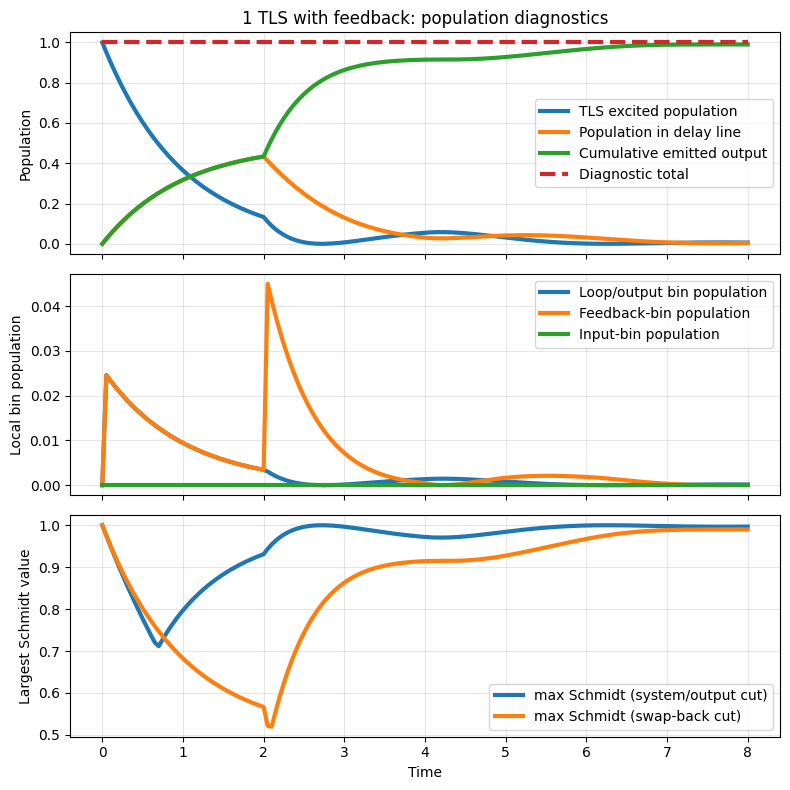

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import wqedlib as qmps


# ============================================================
# Small helpers
# ============================================================
def local_expectation_list(states, op):
    vals = np.array([qmps.expectation_1bin(psi, op) for psi in states], dtype=complex)
    vals = np.real_if_close(vals)
    if np.iscomplexobj(vals):
        vals = vals.real
    return np.asarray(vals, dtype=float)


def moving_window_sum(values: np.ndarray, width: int) -> np.ndarray:
    """
    Running sum over the last `width` points, without any delta_t factor.

    Here the entries are local bin populations <n_k>, so they are already
    dimensionless excitation numbers per bin. Therefore we should sum them
    directly, not integrate with an extra delta_t.
    """
    values = np.asarray(values, dtype=float)
    if width <= 0:
        return np.zeros_like(values)

    csum = np.cumsum(values)
    out = csum.copy()
    if len(values) > width:
        out[width:] = csum[width:] - csum[:-width]
    return out


def print_local_norms(bins, d_sys: int, d_t: int, n_show: int = 5) -> None:
    """
    Print local norms of the first few stored tensors.
    """
    I_sys = np.eye(d_sys, dtype=complex)
    I_t = np.eye(d_t, dtype=complex)

    print("system norms:")
    for k in range(min(n_show, len(bins.system_states))):
        print(f"{k:3d}  {qmps.expectation_1bin(bins.system_states[k], I_sys)}")

    print("loop-field norms:")
    for k in range(min(n_show, len(bins.loop_field_states))):
        print(f"{k:3d}  {qmps.expectation_1bin(bins.loop_field_states[k], I_t)}")

    print("feedback-field norms:")
    for k in range(min(n_show, len(bins.output_field_states))):
        print(f"{k:3d}  {qmps.expectation_1bin(bins.output_field_states[k], I_t)}")

    print("input-field norms:")
    for k in range(min(n_show, len(bins.input_field_states))):
        print(f"{k:3d}  {qmps.expectation_1bin(bins.input_field_states[k], I_t)}")


# ============================================================
# Feedback observables
# ============================================================
def compute_feedback_observables(bins, params) -> dict[str, np.ndarray | float]:
    """
    Build a compact set of observables for the 1-TLS feedback test.

    Conventions used here
    ---------------------
    tls_pop
        Excited-state population of the TLS.

    loop_bin_pop
        Population in the freshly emitted loop/output bin stored at each step.

    feedback_bin_pop
        Population in the delayed feedback bin after it has interacted
        with the TLS and is written back.

    delay_total_pop
        Approximate total population currently stored inside the delay line,
        reconstructed as a moving window sum over the last `delay_steps`
        emitted loop bins.

    emitted_output
        Cumulative population that has already completed the delayed
        interaction, approximated here by the cumulative sum of the
        feedback-bin populations.

    total_excitation
        Diagnostic sum:
            tls_pop + delay_total_pop + emitted_output

        For the single-excitation vacuum-input test this should stay close
        to 1 if the local tensors and bookkeeping are consistent.
    """
    d_sys = params.d_sys
    d_t = params.d_t
    l = params.delay_steps

    n_tls = qmps.tls_pop(d_sys)
    n_bin = qmps.num_op(d_t)

    times = np.asarray(bins.times, dtype=float)

    tls_pop = local_expectation_list(bins.system_states, n_tls)
    loop_bin_pop = local_expectation_list(bins.loop_field_states, n_bin)
    feedback_bin_pop = local_expectation_list(bins.output_field_states, n_bin)
    input_bin_pop = local_expectation_list(bins.input_field_states, n_bin)

    # Population presently inside the delay line:
    # sum of the last l loop bins
    delay_total_pop = moving_window_sum(loop_bin_pop, l)

    # Population that has already passed through the delayed interaction
    emitted_output = np.cumsum(feedback_bin_pop)

    total_excitation = tls_pop + delay_total_pop + emitted_output
    max_abs_error = float(np.max(np.abs(total_excitation - total_excitation[0])))

    return {
        "times": times,
        "tls_pop": tls_pop,
        "loop_bin_pop": loop_bin_pop,
        "feedback_bin_pop": feedback_bin_pop,
        "input_bin_pop": input_bin_pop,
        "delay_total_pop": delay_total_pop,
        "emitted_output": emitted_output,
        "total_excitation": total_excitation,
        "max_abs_error": max_abs_error,
    }


def print_feedback_summary(obs: dict[str, np.ndarray | float]) -> None:
    """
    Print a short textual summary of the main observables.
    """
    print("=" * 72)
    print("times[:8]             =", obs["times"][:8])
    print("tls_pop[:8]           =", obs["tls_pop"][:8])
    print("loop_bin_pop[:8]      =", obs["loop_bin_pop"][:8])
    print("feedback_bin_pop[:8]  =", obs["feedback_bin_pop"][:8])
    print("delay_total_pop[:8]   =", obs["delay_total_pop"][:8])
    print("emitted_output[:8]    =", obs["emitted_output"][:8])
    print("total_excitation[:8]  =", obs["total_excitation"][:8])
    print("-" * 72)
    print("final tls_pop         =", obs["tls_pop"][-1])
    print("final delay_total_pop =", obs["delay_total_pop"][-1])
    print("final emitted_output  =", obs["emitted_output"][-1])
    print("final total           =", obs["total_excitation"][-1])
    print("max |total-total(0)|  =", obs["max_abs_error"])
    print("=" * 72)


def plot_feedback_observables(
    bins, params, obs: dict[str, np.ndarray | float] | None = None
) -> None:
    """
    Plot a compact diagnostic figure for the feedback simulation.
    """
    if obs is None:
        obs = compute_feedback_observables(bins, params)

    times = obs["times"]

    fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.0), sharex=True)

    # --------------------------------------------------------
    # 1. System + total diagnostics
    # --------------------------------------------------------
    axes[0].plot(times, obs["tls_pop"], lw=3, label="TLS excited population")
    axes[0].plot(times, obs["delay_total_pop"], lw=3, label="Population in delay line")
    axes[0].plot(times, obs["emitted_output"], lw=3, label="Cumulative emitted output")
    axes[0].plot(times, obs["total_excitation"], "--", lw=3, label="Diagnostic total")
    axes[0].set_ylabel("Population")
    axes[0].set_title("1 TLS with feedback: population diagnostics")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --------------------------------------------------------
    # 2. Local bin populations
    # --------------------------------------------------------
    axes[1].plot(times, obs["loop_bin_pop"], lw=3, label="Loop/output bin population")
    axes[1].plot(times, obs["feedback_bin_pop"], lw=3, label="Feedback-bin population")
    axes[1].plot(times, obs["input_bin_pop"], lw=3, label="Input-bin population")
    axes[1].set_ylabel("Local bin population")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # --------------------------------------------------------
    # 3. Schmidt diagnostics
    # --------------------------------------------------------
    schmidt_max = np.array(
        [
            np.max(np.asarray(s, dtype=float)) if len(s) > 0 else 0.0
            for s in bins.schmidt
        ]
    )
    schmidt_tau_max = np.array(
        [
            np.max(np.asarray(s, dtype=float)) if len(s) > 0 else 0.0
            for s in bins.schmidt_tau
        ]
    )

    axes[2].plot(times, schmidt_max, lw=3, label="max Schmidt (system/output cut)")
    axes[2].plot(times, schmidt_tau_max, lw=3, label="max Schmidt (swap-back cut)")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Largest Schmidt value")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# Main test
# ============================================================
if __name__ == "__main__":
    params = qmps.parameters.InputParams(
        delta_t=0.05,
        tmax=8.0,
        tau=2.0,
        d_sys_total=np.array([2], dtype=int),
        d_t_total=np.array([2], dtype=int),
        gamma_l=0.5,
        gamma_r=0.5,
        phase=0.0,
        bond_max=18,
        atol=1e-12,
    )

    d_sys = params.d_sys
    d_t = params.d_t

    # Initial state:
    # TLS excited, input field vacuum
    i_s0 = qmps.tls_excited()
    i_n0 = qmps.wg_ground(d_t)

    # Non-Markovian local Hamiltonian
    hm = qmps.hamiltonian_1tls_feedback(params)

    # Time evolution
    bins = qmps.t_evol_nmar_seemps(
        hm,
        i_s0,
        i_n0,
        params,
    )

    # --------------------------------------------------------
    # Basic consistency checks
    # --------------------------------------------------------
    print(f"n_steps                 = {params.steps}")
    print(f"delay_steps             = {params.delay_steps}")
    print(f"len(system_states)      = {len(bins.system_states)}")
    print(f"len(loop_field_states)  = {len(bins.loop_field_states)}")
    print(f"len(output_field_states)= {len(bins.output_field_states)}")
    print(f"len(input_field_states) = {len(bins.input_field_states)}")
    print(f"len(correlation_bins)   = {len(bins.correlation_bins)}")
    print(f"len(schmidt)            = {len(bins.schmidt)}")
    print(f"len(schmidt_tau)        = {len(bins.schmidt_tau)}")
    print(
        f"psi_final norm          = {qmps.expectation_1bin(bins.psi_final, np.eye(d_sys, dtype=complex))}"
    )
    print("-" * 72)

    print_local_norms(bins, d_sys=d_sys, d_t=d_t, n_show=5)

    # --------------------------------------------------------
    # Feedback observables
    # --------------------------------------------------------
    obs = compute_feedback_observables(bins, params)
    print_feedback_summary(obs)
    plot_feedback_observables(bins, params, obs)